# Introduction to OpenStreetMap (OSM) and OSMnx

**Author:** Tianci Guo, Anand Padmanabhan  
**Affiliation:** Department of Geography & GIS, University of Illinois Urbana-Champaign  
**Course:** GGIS 407   

In this notebook, you'll learn:

- What OpenStreetMap (OSM) is and how its data model works?
- How to use the Python library `OSMnx` to download OSM data?
- How to retrieve roads, buildings, and points of interest?
- How to visualize networks and features?
- How to save OSM data to shapefiles and/or other formats?

## 1. Introduction to OSM

[OpenStreetMap](https://www.openstreetmap.org/) is a collaborative project to create a free, editable map of the world. It contains data for example about streets, buildings, different services, and landuse to mention a few.

Key concepts:

- **Volunteered Geographic Information (VGI):** OSM is built by volunteers who collect and edit data.
- **Data model:**
  - **Nodes:** Points with a latitude and longitude (e.g., a traffic signal or a POI).
  - **Ways:** Ordered lists of nodes representing lines or polygons (e.g., roads, buildings).
  - **Relations:** Logical or geographic relationships between objects (e.g., bus routes, multipolygons).
- **Tags:** Key–value pairs that describe features (e.g., `highway=residential`, `amenity=cafe`).

We will not edit OSM in this course, but we will **consume** OSM data for analysis and visualization. You can also sign up as a contributor if you want to edit the map. More details about OpenStreetMap and its contents are available in the [OpenStreetMap Wiki](https://wiki.openstreetmap.org/wiki/Main_Page).  

OSM data is described using tags, which are simple key = value pairs.  
### Common Tag Categories  
| Category      | Key                | Example Values                      | Meaning              |
| ------------- | ------------------ | ----------------------------------- | -------------------- |
| **Roads**     | `highway`          | `primary`, `residential`, `footway` | Type of road or path |
| **Buildings** | `building`         | `yes`, `house`, `school`            | Building footprint   |
| **Land Use**  | `landuse`          | `residential`, `commercial`         | Land use type        |
| **POIs**      | `amenity`          | `cafe`, `restaurant`, `library`     | Common services      |
| **Transport** | `public_transport` | `platform`, `stop_position`         | Transit features     |


## 2. Introduction to OSMnx

[OSMnx](https://github.com/gboeing/osmnx) is a Python library for:

- Downloading OSM data (streets, buildings, POIs) by **place name**, **address**, or **bounding box**
- Creating **street network graphs** for routing and network analysis
- Projecting, visualizing, and saving geospatial data

> Reference: Boeing, G. (2017). *OSMnx: New methods for acquiring, constructing, analyzing, and visualizing complex street networks.*

## 3. Setup & imports
Run the cell below to import OSMnx, GeoPandas, and Matplotlib.

In [ ]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd 
import contextily as cx

ox.settings.use_cache = True
ox.settings.log_console = True

print('OSMnx version:', ox.__version__)

OSMnx version: 1.2.2


## 4. Getting Place Boundaries with OSMnx

`osmnx.geocode_to_gdf()` can transform a place name, ZIP code, or administrative region into its corresponding boundary polygon.

This is useful for defining *areas of interest* before extracting networks.

In [ ]:
# Get the city boundaries and campus polygon
# Each geocode_to_gdf() call returns a GeoDataFrame containing the boundary polygon
champaign = ox.geocode_to_gdf('Champaign, Illinois, USA')
urbana = ox.geocode_to_gdf('Urbana, Illinois, USA')
uiuc = ox.geocode_to_gdf('University of Illinois Urbana-Champaign')

display(champaign, urbana, uiuc)

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-88.31397 40.06952, -88.31379 40.069...",40.16398,40.061858,-88.221223,-88.333372,344454752,relation,126114,40.116484,-88.243093,boundary,administrative,16,0.586644,city,Champaign,"Champaign, Champaign County, Illinois, United ..."


,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-88.23292 40.13241, -88.23199 ...",40.157339,40.072872,-88.15306,-88.232915,344725648,relation,126133,40.111717,-88.207301,boundary,administrative,16,0.576065,city,Urbana,"Urbana, Champaign County, Illinois, United States"


,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-88.29098 40.05014, -88.28921 ...",40.11634,40.026113,-88.190258,-88.290982,345040847,relation,12299045,40.076155,-88.223313,amenity,university,30,0.598284,amenity,University of Illinois Urbana-Champaign,"University of Illinois Urbana-Champaign, Champ..."


In [ ]:
# Get the city boundaries and campus polygon
# Each geocode_to_gdf() call returns a GeoDataFrame containing the boundary polygon
champaign = ox.geocode_to_gdf('Champaign, Illinois, USA')
urbana = ox.geocode_to_gdf('Urbana, Illinois, USA')
uiuc = ox.geocode_to_gdf('University of Illinois Urbana-Champaign')

display(champaign, urbana, uiuc)

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-88.31397 40.06952, -88.31379 40.069...",40.16398,40.061858,-88.221223,-88.333372,344454752,relation,126114,40.116484,-88.243093,boundary,administrative,16,0.586644,city,Champaign,"Champaign, Champaign County, Illinois, United ..."


,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-88.23292 40.13241, -88.23199 ...",40.157339,40.072872,-88.15306,-88.232915,344725648,relation,126133,40.111717,-88.207301,boundary,administrative,16,0.576065,city,Urbana,"Urbana, Champaign County, Illinois, United States"


,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-88.29098 40.05014, -88.28921 ...",40.11634,40.026113,-88.190258,-88.290982,345040847,relation,12299045,40.076155,-88.223313,amenity,university,30,0.598284,amenity,University of Illinois Urbana-Champaign,"University of Illinois Urbana-Champaign, Champ..."


### Plotting the Boundaries

Let's plot Champaign, Urbana, and the UIUC campus together.

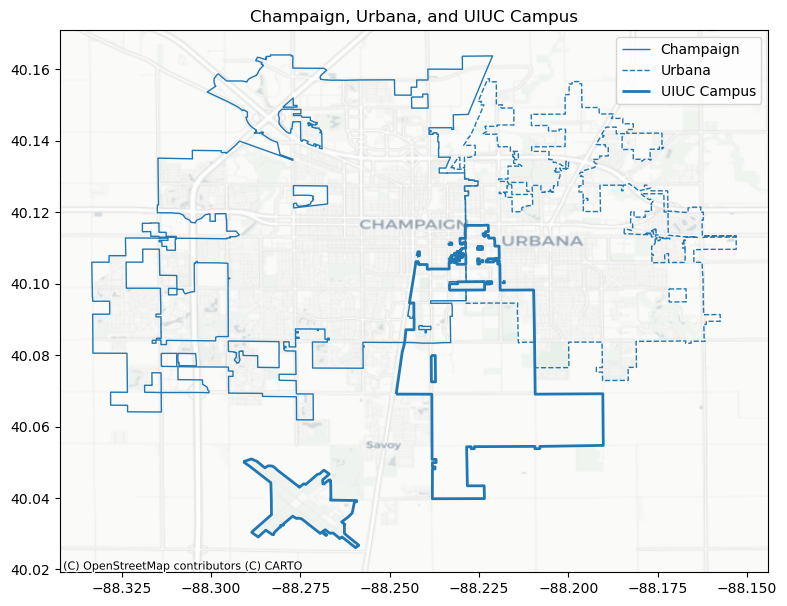

In [ ]:
# Unify the GeoDataFrames for plotting and to get the combined extent
combined = gpd.GeoDataFrame(pd.concat([champaign, urbana, uiuc], ignore_index=True), 
                            crs=champaign.crs)

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the boundaries
champaign.boundary.plot(ax=ax, label='Champaign', linewidth=1)
urbana.boundary.plot(ax=ax, label='Urbana', linewidth=1, linestyle='--')
uiuc.boundary.plot(ax=ax, label='UIUC Campus', linewidth=2)

# Add a basemap
cx.add_basemap(ax=ax, crs=combined.crs.to_string(), source=cx.providers.CartoDB.Positron)

ax.set_title('Champaign, Urbana, and UIUC Campus')
ax.legend()
plt.tight_layout()
plt.show()

### Additional examples

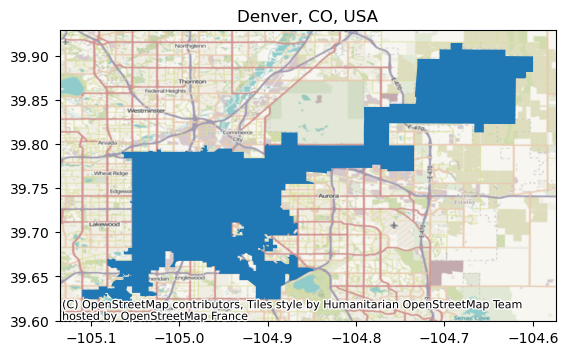

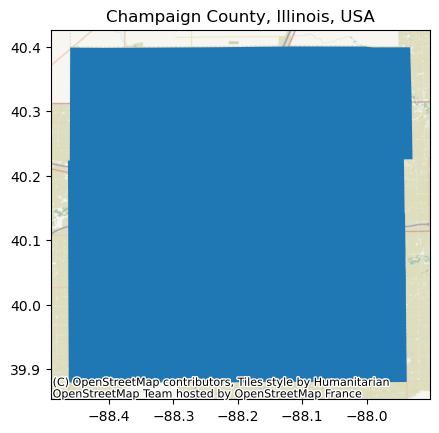

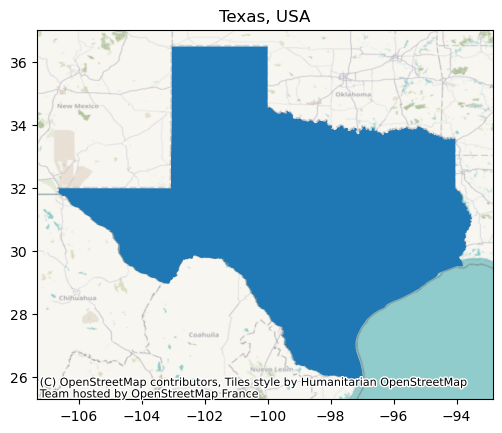

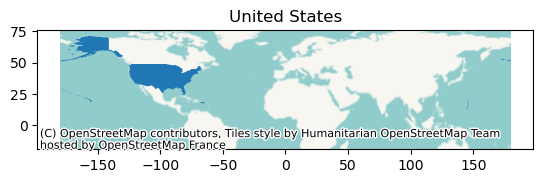

In [ ]:
import contextily as cx

# List of place names at different geographic scales
queries = [
    "Denver, CO, USA", # city
    "Champaign County, Illinois, USA", # county
    "Texas, USA", # state
    "United States" # country
]

# Loop through each place name
for q in queries:
    # Retrieve the boundary polygon for the place using OSM geocoding.
    # The result is returned as a GeoDataFrame.
    tmp = ox.geocode_to_gdf(q)
    
    # Plot the boundary geometry
    ax = tmp.plot()
    
    # Add a basemap underneath the boundary.
    # contextily needs the CRS to correctly align the basemap.
    cx.add_basemap(ax=ax, crs=tmp.crs.to_string())
    
    # Add a descriptive title showing which place is being plotted
    ax.set_title(q)
    
    # Display the figure
    plt.show()

## 5. Get Street Networks

OSMnx can download a street network graph for a specified place.  

`graph_from_place()` returns a NetworkX MultiDiGraph, representing a street network:

 - Nodes = intersections, endpoints
 - Edges = street segments
 - Attributes include length, highway type, speed, name, etc.

This object is not a GeoDataFrame — it is a graph designed for:

 - Routing / shortest paths
 - Graph statistics
 - Connectivity analysis
 - Network visualization

We will work with:

- A **driving** network for Champaign–Urbana
- A **walking** network for the UIUC campus

In [ ]:
# Define the places we want to download the driving network for:
# Champaign and Urbana together form the metro area around UIUC.
places_cu = ["Champaign, Illinois, USA", "Urbana, Illinois, USA"]

# Download the street network for driving for the combined area.
# network_type="drive" keeps only drivable roads (no footpaths, no alleys).
G_drive = ox.graph_from_place(places_cu, network_type="drive")

# Download the walking network specifically for the UIUC campus area.
# network_type="walk" includes footpaths, sidewalks, pedestrian areas, and other walkable connections used by pedestrians.
G_walk_uiuc = ox.graph_from_place(
    'University of Illinois Urbana-Champaign',
    network_type='walk'
)

# Display the two graphs (useful for confirming they were created successfully)
G_drive, G_walk_uiuc

(<networkx.classes.multidigraph.MultiDiGraph at 0x7f15ec402b50>,
 <networkx.classes.multidigraph.MultiDiGraph at 0x7f15e7ae3130>)

### Plot the Driving Network for Champaign–Urbana

In [ ]:
# Project the graph to Web Mercator (required for basemaps)
G_drive_proj = ox.project_graph(G_drive, to_crs="EPSG:3857")

fig, ax = ox.plot_graph(G_drive_proj, bgcolor='white', node_size=0, 
                        edge_linewidth=0.5,edge_color='blue',
                        show=False, close=False)

# Add basemap
cx.add_basemap(ax, crs="EPSG:3857")

plt.show()

### Plot the Walking Network on the UIUC Campus

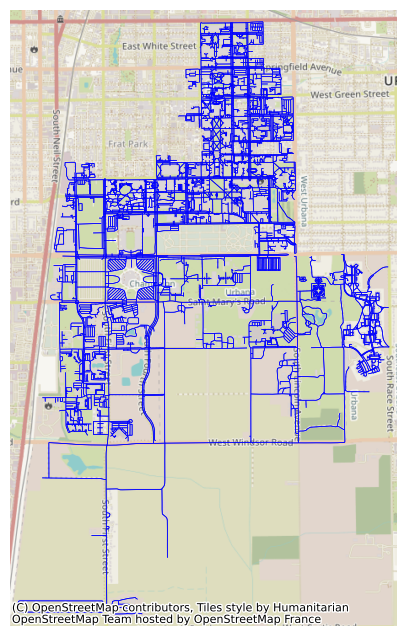

In [ ]:
# Project the graph to Web Mercator (required for basemaps)
G_walk_uiuc_proj = ox.project_graph(G_walk_uiuc, to_crs="EPSG:3857")

# Plot the graph but keep the axis open for adding layers
fig, ax = ox.plot_graph(G_walk_uiuc_proj, bgcolor='white', node_size=0, 
                        edge_linewidth=0.5,edge_color='blue',
                        show=False, close=False)

# Add basemap
cx.add_basemap(ax, crs="EPSG:3857")

plt.show()

## 6. Converting the Network to GeoDataFrames

OSMnx can convert a network graph into **nodes** and **edges** GeoDataFrames by `ox.graph_to_gdfs()`, which we can inspect and filter.  
 - nodes_gdf — Point geometries
 - edges_gdf — LineString geometries (street segments)  

Let's do this for the UIUC walking network.

In [ ]:
# Convert the walking network graph into GeoDataFrames:
# - nodes_uiuc: contains node locations (points)
# - edges_uiuc: contains street segments connecting nodes (lines)
nodes_uiuc, edges_uiuc = ox.graph_to_gdfs(G_walk_uiuc)

# Display the first few rows of each GeoDataFrame
# This helps verify the structure and attributes of nodes and edges
display(nodes_uiuc.head(), edges_uiuc.head())

,y,x,street_count,highway,geometry
osmid,,,,,
37945976,40.092331,-88.242063,1,NaN,POINT (-88.24206 40.09233)
37947044,40.088701,-88.218932,3,NaN,POINT (-88.21893 40.08870)
37947069,40.088759,-88.216258,3,NaN,POINT (-88.21626 40.08876)
37947072,40.087338,-88.216148,3,NaN,POINT (-88.21615 40.08734)
37947075,40.087475,-88.216266,3,NaN,POINT (-88.21627 40.08747)


osmid    highway  oneway reversed   length   
u        v           key                                                   
37945976 5427442294  0    563118931    service   False     True   28.624  \
37947044 6876432992  0    339174376  secondary   False    False   17.403   
         13167008437 0    339174376  secondary   False     True   42.401   
         37947069    0      5324654    service   False    False  233.245   
37947069 37947044    0      5324654    service   False     True  233.245   

                                          name maxspeed   
u        v           key                                  
37945976 5427442294  0                     NaN      NaN  \
37947044 6876432992  0    South Lincoln Avenue   35 mph   
         13167008437 0    South Lincoln Avenue   35 mph   
         37947069    0                     NaN      NaN   
37947069 37947044    0                     NaN      NaN   

                                                                   geometry   
u        v           key                                                      
37945976 5427442294  0    LINESTRING (-88.24206 40.09233, -88.24205 40.0...  \
37947044 6876432992  0    LINESTRING (-88.21893 40.08870, -88.21893 40.0...   
         13167008437 0    LINESTRING (-88.21893 40.08870, -88.21894 40.0...   
         37947069    0    LINESTRING (-88.21893 40.08870, -88.21728 40.0...   
37947069 37947044    0    LINESTRING (-88.21626 40.08876, -88.21665 40.0...   

                         lanes  ref service tunnel access bridge area   
u        v           key                                                
37945976 5427442294  0     NaN  NaN     NaN    NaN    NaN    NaN  NaN  \
37947044 6876432992  0     NaN  NaN     NaN    NaN    NaN    NaN  NaN   
         13167008437 0     NaN  NaN     NaN    NaN    NaN    NaN  NaN   
         37947069    0     NaN  NaN     NaN    NaN    NaN    NaN  NaN   
37947069 37947044    0     NaN  NaN     NaN    NaN    NaN    NaN  NaN   

                         est_width  
u        v           key            
37945976 5427442294  0         NaN  
37947044 6876432992  0         NaN  
         13167008437 0         NaN  
         37947069    0         NaN  
37947069 37947044    0         NaN

### Visualize Nodes and Edges

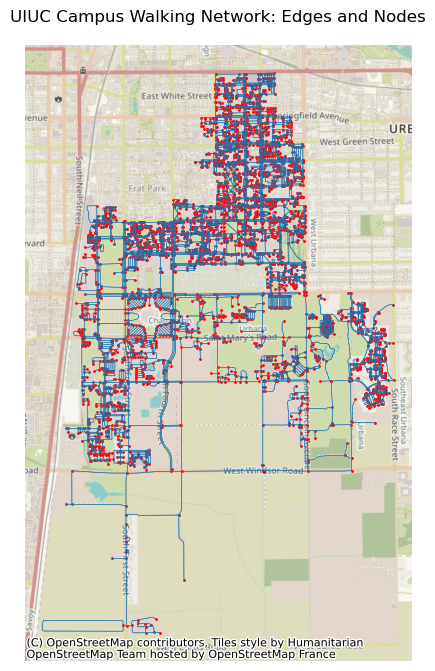

In [ ]:
#Project to Web Mercator for basemap compatibility
nodes_uiuc_proj = nodes_uiuc.to_crs(epsg=3857)
edges_uiuc_proj = edges_uiuc.to_crs(epsg=3857)

# Plot edges and nodes
fig, ax = plt.subplots(figsize=(8, 8))
edges_uiuc_proj.plot(ax=ax, linewidth=0.4)
nodes_uiuc_proj.plot(ax=ax, markersize=1, color='red')

# Add basemap
cx.add_basemap(ax, crs=edges_uiuc_proj.crs)

ax.set_title('UIUC Campus Walking Network: Edges and Nodes')
ax.set_axis_off()
plt.show()

## 7. Retrieving Features: Buildings and Points of Interest

OSMnx’s `geometries_from_place` and `geometries_from_bbox` functions allow us to retrieve any OSM features using tag dictionaries.

Features are defined by tags, such as:

- Buildings: `{'building': True}`  
- Cafes: `{'amenity': 'cafe'}`  
- Bus stops: `{'highway': 'bus_stop'}`



### 7.1 Retrieve Features by Coordinates (Bounding Box)
Use `geometries_from_bbox` when you want data for a rectangle defined by latitude/longitude.  
We will focus on features around the **UIUC campus**.

In [ ]:
# Define a bounding box around the UIUC campus using latitude and longitude
north = 40.1205
south = 40.0950
east  = -88.2100
west  = -88.2450

# Retrieve all building footprints within the bounding box from OpenStreetMap
# "tags={"building": True}" means we only want features with a "building" tag
buildings_uiuc = ox.geometries_from_bbox(
    north, south, east, west,
    tags={"building": True}
)

# Display the first few rows of the GeoDataFrame
buildings_uiuc.head()

addr:state building  ele gnis:feature_id   
element_type osmid                                                 
node         368073697          IL      yes  223         1810710  \
             2384922612        NaN      yes  NaN             NaN   
             2423728488        NaN      yes  NaN             NaN   
             2424357407        NaN      yes  NaN             NaN   
             2433235014        NaN      yes  NaN             NaN   

                                                name         source   
element_type osmid                                                    
node         368073697       Armory Avenue Warehouse  USGS Geonames  \
             2384922612              Signature Grill            NaN   
             2423728488  Fuad's Creative Hair Design            NaN   
             2424357407                    Delta Chi            NaN   
             2433235014                          NaN            NaN   

                                           geometry        amenity   
element_type osmid                                                   
node         368073697   POINT (-88.24227 40.10586)            NaN  \
             2384922612  POINT (-88.23132 40.11011)      fast_food   
             2423728488  POINT (-88.23895 40.11212)            NaN   
             2424357407  POINT (-88.23908 40.10461)  social_centre   
             2433235014  POINT (-88.23840 40.10635)            NaN   

                               cuisine drive_through  ... information   
element_type osmid                                    ...               
node         368073697             NaN           NaN  ...         NaN  \
             2384922612  indian;fusion            no  ...         NaN   
             2423728488            NaN           NaN  ...         NaN   
             2424357407            NaN           NaN  ...         NaN   
             2433235014            NaN           NaN  ...         NaN   

                        hairdresser disused fast_food building:min_level   
element_type osmid                                                         
node         368073697          NaN     NaN       NaN                NaN  \
             2384922612         NaN     NaN       NaN                NaN   
             2423728488         NaN     NaN       NaN                NaN   
             2424357407         NaN     NaN       NaN                NaN   
             2433235014         NaN     NaN       NaN                NaN   

                        bicycle_parking ways nrhp:criteria url:map ref:isil  
element_type osmid                                                           
node         368073697              NaN  NaN           NaN     NaN      NaN  
             2384922612             NaN  NaN           NaN     NaN      NaN  
             2423728488             NaN  NaN           NaN     NaN      NaN  
             2424357407             NaN  NaN           NaN     NaN      NaN  
             2433235014             NaN  NaN           NaN     NaN      NaN  

[5 rows x 214 columns]

To understand the variety of OSM tags, you can print unique values.

In [ ]:
# Find all building types and drop note available
buildings_uiuc['building'].dropna().unique()

array(['yes', 'apartments', 'house', 'university', 'roof', 'stadium',
       'greenhouse', 'public', 'parking', 'church', 'dormitory',
       'data_center', 'mosque', 'chapel', 'school', 'train_station',
       'civic', 'commercial', 'retail', 'bank', 'residential', 'barracks',
       'storage_tank', 'hospital', 'office', 'yes;apartments',
       'healthcare', 'garage', 'detached', 'theatre', 'garages',
       'college', 'bridge', 'grandstand', 'semidetached_house',
       'residential;house', 'pavilion', 'no', 'warehouse',
       'social_facility', 'shed', 'hotel', 'apartments;yes'], dtype=object)

#### Plot Campus Buildings

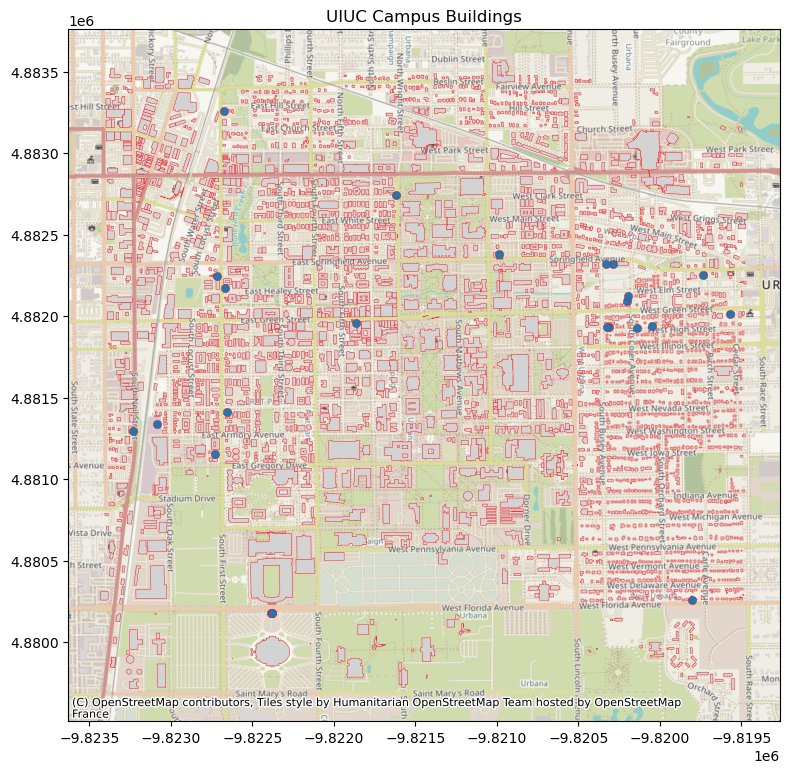

In [ ]:
# Project to Web Mercator (required for basemap)
buildings_uiuc_proj = buildings_uiuc.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot buildings
buildings_uiuc_proj.plot(ax=ax, facecolor='lightgray', edgecolor='red', linewidth=0.3)
# Add basemap
cx.add_basemap(ax, crs=buildings_uiuc_proj.crs)

# Title and layout
ax.set_title('UIUC Campus Buildings')
plt.tight_layout()
plt.show()

#### Why do some buildings appear as blue points?

When you retrieve buildings using:

`buildings_uiuc = ox.geometries_from_place(..., {"building": True})`

OpenStreetMap returns **all features that contain the tag** `building=*`.  
These features may have different geometry types:

- **Polygon** - full building footprint (most common)
- **MultiPolygon** - complex building outlines
- **LineString** - rare; sometimes used for building outlines under construction
- **Point** - a single node tagged as a building

Some OpenStreetMap contributors map buildings only as **points**, typically when no detailed footprint is available.  
OSMnx preserves all geometry types exactly as they exist in the OSM database.

Therefore, when you plot the resulting GeoDataFrame:

- **Polygons** appear as building shapes
- **Points** appear as small markers (often displayed as default blue dots)

If you want to display only building footprints, you can filter polygons using:


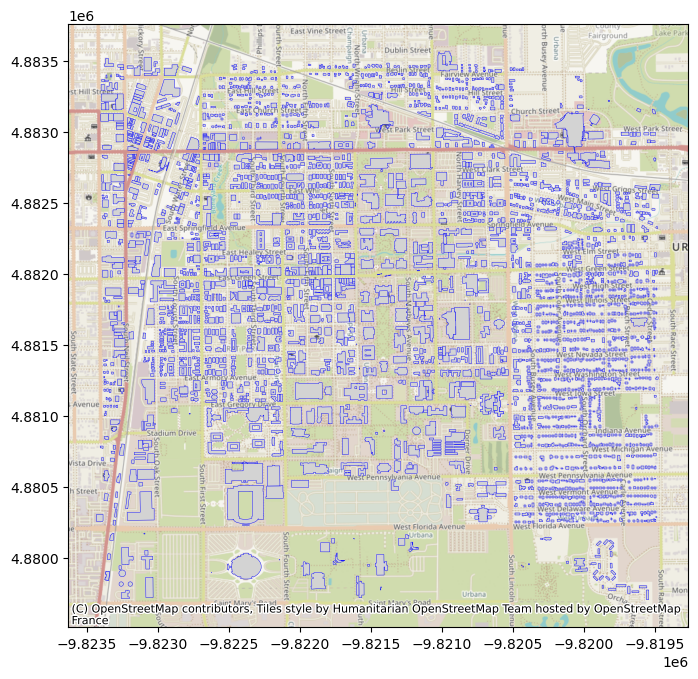

In [ ]:
# Keep only Polygon or MultiPolygon types
buildings_poly = buildings_uiuc[buildings_uiuc.geometry.type.isin(["Polygon", "MultiPolygon"])]

# Reproject to Web Mercator for basemap
buildings_poly_proj = buildings_poly.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
buildings_poly_proj.plot(ax=ax, facecolor='lightgray', edgecolor='blue', linewidth=0.3)

# Add basemap
cx.add_basemap(ax, crs=buildings_poly_proj.crs)

### 7.2 Retrieve Features by Place Name

Use `geometries_from_place` when you want OSM data for an administrative region or named location.  
We can query what amenities are present.

In [ ]:
# Define the place for which we want to extract amenities
campus_place = 'University of Illinois Urbana-Champaign'

# Download all geometries from OSM within the campus boundary
# that have an "amenity" tag (True means: return any value of 'amenity')
amenity_values = ox.geometries_from_place(
    campus_place,
    {"amenity": True}
)

# Extract the "amenity" column, remove missing values,
# and list all unique amenity types found on campus
amenity_values['amenity'].dropna().unique()

array(['bicycle_parking', 'parking', 'fast_food', 'restaurant', 'atm',
       'bench', 'car_rental', 'parking_entrance', 'post_office', 'cafe',
       'fountain', 'vending_machine', 'post_box', 'toilets',
       'drinking_water', 'conference_centre', 'motorcycle_parking',
       'charging_station', 'bicycle_repair_station', 'shelter', 'library',
       'waste_disposal', 'public_bookcase', 'pharmacy', 'loading_dock',
       'bank', 'car_sharing', 'waste_basket', 'police', 'piano',
       'photo_booth', 'recycling', 'clock', 'clinic', 'social_centre',
       'research_institute', 'ticket_validator', 'theatre',
       'washing_machine', 'arts_centre', 'fire_station', 'veterinary',
       'nightclub', 'dancing_school', 'school', 'food_court', 'bar',
       'university'], dtype=object)

We can query for cafes and coffee-related amenities near Green Street / Campustown.

In [ ]:
# Define the OSM tags we want to extract:
# - amenity = cafe or fast_food
# - cuisine = coffee_shop
# This helps capture cafés and places serving coffee on campus.
tags_cafes = {'amenity': ['cafe', 'fast_food'], 'cuisine': 'coffee_shop'}

# Query all OSM geometries within the campus boundary that match the tags above (café-type amenities)
cafes_uiuc = ox.geometries_from_place(campus_place, tags_cafes)

# Display the first few rows, showing:
# - name: the café or shop name (if available)
# - amenity: the amenity category returned by OSM
# - geometry: the spatial location (Point or Polygon)
cafes_uiuc[['name', 'amenity', 'geometry']].head()

name    amenity   
element_type osmid                                          
node         1513700911  Ikenberry Dining Hall  fast_food  \
             2180208075             Array Cafe       cafe   
             2276335071           Beckman Cafe       cafe   
             2433234768                 I Café       cafe   
             2806834843              Starbucks       cafe   

                                           geometry  
element_type osmid                                   
node         1513700911  POINT (-88.23532 40.10384)  
             2180208075  POINT (-88.22543 40.10503)  
             2276335071  POINT (-88.22776 40.11586)  
             2433234768  POINT (-88.23756 40.09361)  
             2806834843  POINT (-88.22907 40.10822)

#### Map Cafes near UIUC

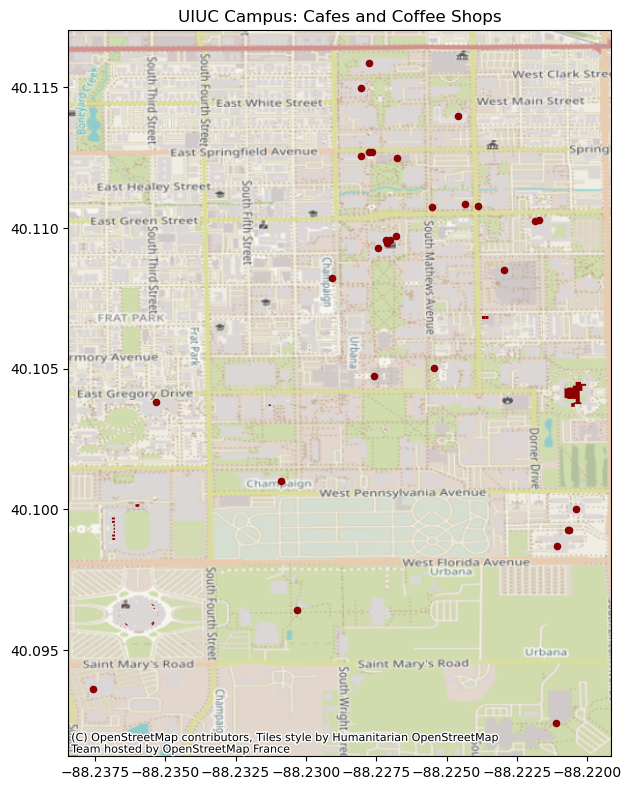

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot cafes
cafes_uiuc.plot(ax=ax, color='darkred', markersize=20)
# Add basemap
cx.add_basemap(ax, crs=cafes_uiuc.crs)

ax.set_title('UIUC Campus: Cafes and Coffee Shops')
plt.tight_layout()
plt.show()

### 7.3. Filtering Streets by Type

We can filter edges based on the `highway` tag.  

Now, we have a driving network for Champaign–Urbana named `G_drive`. First, let's take a look at what highway types appear in the network.


In [ ]:
# Convert the graph into GeoDataFrames for nodes and edges
nodes_cu, edges_cu = ox.graph_to_gdfs(G_drive)

# Extract the "highway" column and drop rows where the value is missing (NaN)
highway_vals = edges_cu['highway'].dropna()

# Find all unique highway types in the dataset
unique_highways = (
    highway_vals
    # Each "highway" value might be a string or a list (OSM can store multiple tags)
    # → Convert strings to single-item lists so we can handle them uniformly
    .apply(lambda x: x if isinstance(x, list) else [x])  
    # Flatten all lists into one long series of individual highway types
    .explode()                                           
    # Sort for easier reading
    .sort_values()
    # Get unique values
    .unique()
)

# Display all unique highway categories found in the graph
unique_highways

array(['motorway', 'motorway_link', 'primary', 'primary_link',
       'residential', 'secondary', 'secondary_link', 'tertiary',
       'tertiary_link', 'unclassified'], dtype=object)

Then, let's show only **primary** and **secondary** roads around Champaign–Urbana.

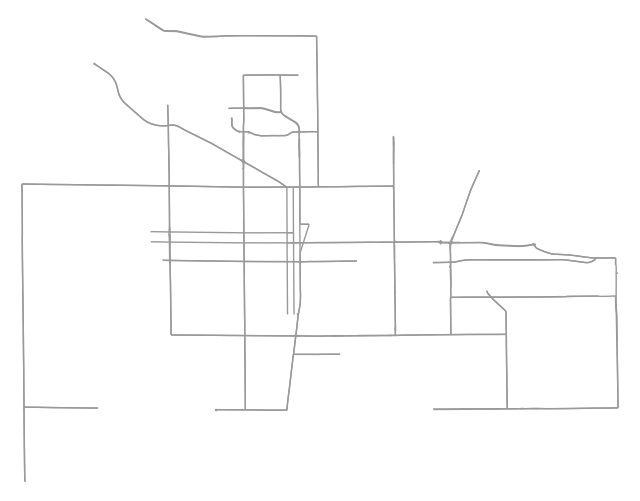

In [ ]:
# Download the driving network for Champaign–Urbana, but keep only primary and secondary roads.
# - network_type='drive' ensures only drivable streets are included.
# - retain_all=True keeps all disconnected subgraphs instead of just the largest.
# - custom_filter='["highway"~"primary|secondary"]' filters for primary and secondary highways only.
G_primary = ox.graph_from_place(
    places_cu,
    network_type='drive',
    retain_all=True,
    custom_filter='["highway"~"primary|secondary"]'
)

fig, ax = ox.plot_graph(G_primary, bgcolor='white', node_size=0, edge_linewidth=1)

## 8. OSM Write Features to .shp

Now let’s assume we want to access this data outside of python, or have a permanent copy of our building footprints for UIUC campus.  

Although these objects are already `geopandas.GeoDataFrame`, We can’t write OSM GeoDataFrames directly to disk because they contain field types (like lists) that can’t be saved in `.shp` or `.geojsons` etc. Instead lets isolate only the attributes we are interested in, **including geometry** which is required.  

We need to isolate just the attributes we are interested in:



In [ ]:
# Select only the columns that we are interested in keeping from the GeoDataFrame
# - 'addr:' selects all columns containing address information (e.g., addr:housenumber, addr:street)
# - 'geometry' ensures we keep the spatial geometry of each building, which is required for GIS operations
buildings_uiuc_exp = buildings_uiuc.loc[:,buildings_uiuc.columns.str.contains('addr:|geometry')]

OSM data often contains multiple feature types like mixing points with polygons. This is a problem when we try to write it to disk.  

We also need to isolate the feature type we are looking for [e.g. Multipolygon, Polygon, Point]. Since here we want building footprints we are going to keep only polygons.

In [ ]:
buildings_uiuc_exp = buildings_uiuc_exp.loc[buildings_uiuc_exp.geometry.type=='Polygon']

Now, finally, we can write it to disk.


In [ ]:
# Save building footprints to a Shapefile
buildings_uiuc_exp.to_file('uiuc_buildings.shp')  

# Alternatively, save in a more open-source and flexible format like GeoJSON
buildings_uiuc_exp.to_file('uiuc_buildings.geojson', driver='GeoJSON')  

/tmp/ipykernel_279/4004416074.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  buildings_uiuc_exp.to_file('uiuc_buildings.shp')


## 9. Data Cleaning and Pre-processing of OSM Data

During the earlier exercises in this notebook, several patterns emerged when working with OSM queries.
For example, building extractions included points and polygons together, street attributes sometimes contained lists, and many feature tables included a large number of rarely used or empty columns. These issues are common in crowdsourced datasets like OSM and must be addressed before performing spatial analysis, visualization, or exporting results to GIS formats.

This section summarizes the most important cleaning and preprocessing steps that help ensure consistent and usable OSM datasets.

### 9.1 Mixed Geometry Types

OSM queries often return heterogeneous geometries in a single GeoDataFrame:

- Points
- LineStrings
- Polygons
- MultiPolygons

For example, buildings retrieved with `{"building": True}` may appear as points or polygons.
To work with building footprints, keep only polygon-based geometries:

In [ ]:
# Keep only Polygon and MultiPolygon geometries.
# This removes points and lines that are not building footprints.
buildings_uiuc_clean = buildings_uiuc[buildings_uiuc.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

This avoids errors when saving data to shapefiles and ensures consistent geometry types.

### 9.2. Removing Unusable or Empty Attributes

OSM-derived GeoDataFrames often contain dozens or even hundreds of attribute fields because OpenStreetMap supports an open tagging system. Each contributor may add different tags to a feature (e.g., `building:levels`, `addr:street`, `amenity`, `operator`, `opening_hours`, etc.). Therefore, the first step is to inspect which attributes are present and evaluate what is relevant for your analysis or export format.

You can check the available fields by examining the columns of the GeoDataFrame:

In [ ]:
# Display all attribute names in the dataset
list(buildings_uiuc.columns)

['addr:state',
 'building',
 'ele',
 'gnis:feature_id',
 'name',
 'source',
 'geometry',
 'amenity',
 'cuisine',
 'drive_through',
 'wheelchair',
 'addr:city',
 'addr:housenumber',
 'addr:street',
 'contact:email',
 'contact:phone',
 'contact:website',
 'opening_hours',
 'shop',
 'addr:postcode',
 'building:levels',
 'fixme',
 'operator',
 'website',
 'level',
 'access',
 'addr:country',
 'check_date',
 'parking',
 'emergency',
 'email',
 'fax',
 'phone',
 'ref',
 'bench',
 'bin',
 'note',
 'nodes',
 'building:material',
 'name:etymology',
 'name:etymology:description',
 'name:etymology:wikidata',
 'name:etymology:wikipedia',
 'wikidata',
 'wikipedia',
 'old_name',
 'short_name',
 'layer',
 'long_name',
 'roof:levels',
 'alt_name',
 'height',
 'internet_access',
 'operator:type',
 'healthcare',
 'start_date',
 'service:bicycle:diy',
 'service:bicycle:sales',
 'leisure',
 'sport',
 'building:levels:underground',
 'fee',
 'official_name',
 'man_made',
 'tower',
 'tower:construction',
 't

To quickly preview non-empty columns:

In [ ]:
# Show only columns containing at least one non-null value
buildings_uiuc.loc[:, buildings_uiuc.notna().any()].head()

addr:state building  ele gnis:feature_id   
element_type osmid                                                 
node         368073697          IL      yes  223         1810710  \
             2384922612        NaN      yes  NaN             NaN   
             2423728488        NaN      yes  NaN             NaN   
             2424357407        NaN      yes  NaN             NaN   
             2433235014        NaN      yes  NaN             NaN   

                                                name         source   
element_type osmid                                                    
node         368073697       Armory Avenue Warehouse  USGS Geonames  \
             2384922612              Signature Grill            NaN   
             2423728488  Fuad's Creative Hair Design            NaN   
             2424357407                    Delta Chi            NaN   
             2433235014                          NaN            NaN   

                                           geometry        amenity   
element_type osmid                                                   
node         368073697   POINT (-88.24227 40.10586)            NaN  \
             2384922612  POINT (-88.23132 40.11011)      fast_food   
             2423728488  POINT (-88.23895 40.11212)            NaN   
             2424357407  POINT (-88.23908 40.10461)  social_centre   
             2433235014  POINT (-88.23840 40.10635)            NaN   

                               cuisine drive_through  ... climbing:toprope   
element_type osmid                                    ...                    
node         368073697             NaN           NaN  ...              NaN  \
             2384922612  indian;fusion            no  ...              NaN   
             2423728488            NaN           NaN  ...              NaN   
             2424357407            NaN           NaN  ...              NaN   
             2433235014            NaN           NaN  ...              NaN   

                        information hairdresser disused fast_food   
element_type osmid                                                  
node         368073697          NaN         NaN     NaN       NaN  \
             2384922612         NaN         NaN     NaN       NaN   
             2423728488         NaN         NaN     NaN       NaN   
             2424357407         NaN         NaN     NaN       NaN   
             2433235014         NaN         NaN     NaN       NaN   

                        building:min_level ways nrhp:criteria url:map ref:isil  
element_type osmid                                                              
node         368073697                 NaN  NaN           NaN     NaN      NaN  
             2384922612                NaN  NaN           NaN     NaN      NaN  
             2423728488                NaN  NaN           NaN     NaN      NaN  
             2424357407                NaN  NaN           NaN     NaN      NaN  
             2433235014                NaN  NaN           NaN     NaN      NaN  

[5 rows x 208 columns]

You can also drop entirely empty columns:

In [ ]:
# Make a copy of the original cafes dataset to avoid modifying it directly
gdf = cafes_uiuc.copy()

gdf_clean = gdf.dropna(axis=1, how="all")
gdf_clean.head()

addr:city addr:housenumber addr:postcode   
element_type osmid                                                  
node         1513700911        NaN              NaN           NaN  \
             2180208075        NaN              NaN           NaN   
             2276335071        NaN              NaN           NaN   
             2433234768        NaN              NaN           NaN   
             2806834843  Champaign              809         61820   

                                 addr:street    amenity   
element_type osmid                                        
node         1513700911                  NaN  fast_food  \
             2180208075                  NaN       cafe   
             2276335071                  NaN       cafe   
             2433234768                  NaN       cafe   
             2806834843  South Wright Street       cafe   

                                            email internet_access   
element_type osmid                                                  
node         1513700911                       NaN             NaN  \
             2180208075                       NaN             NaN   
             2276335071  beckmancafe@illinois.edu             NaN   
             2433234768                       NaN             NaN   
             2806834843                       NaN             NaN   

                                          name      opening_hours   
element_type osmid                                                  
node         1513700911  Ikenberry Dining Hall                NaN  \
             2180208075             Array Cafe  Mo-Fr 08:00-15:00   
             2276335071           Beckman Cafe  Mo-Fr 08:30-14:00   
             2433234768                 I Café        06:00-19:00   
             2806834843              Starbucks        07:00-23:00   

                                   phone  ... street_vendor fast_food   
element_type osmid                        ...                           
node         1513700911              NaN  ...           NaN       NaN  \
             2180208075              NaN  ...           NaN       NaN   
             2276335071              NaN  ...           NaN       NaN   
             2433234768              NaN  ...           NaN       NaN   
             2806834843  +1 217-244-1775  ...           NaN       NaN   

                        internet_access:fee internet_access:ssid   
element_type osmid                                                 
node         1513700911                 NaN                  NaN  \
             2180208075                 NaN                  NaN   
             2276335071                 NaN                  NaN   
             2433234768                 NaN                  NaN   
             2806834843                 NaN                  NaN   

                        diet:vegetarian operator fixme:atp nodes indoor layer  
element_type osmid                                                             
node         1513700911             NaN      NaN       NaN   NaN    NaN   NaN  
             2180208075             NaN      NaN       NaN   NaN    NaN   NaN  
             2276335071             NaN      NaN       NaN   NaN    NaN   NaN  
             2433234768             NaN      NaN       NaN   NaN    NaN   NaN  
             2806834843             NaN      NaN       NaN   NaN    NaN   NaN  

[5 rows x 35 columns]


The decisioof which attributes to retain n depends on **your analytical goals** and **GIS export constraints**.  
In practice, attribute selection typically follows the criteria below.

#### **1. Required Columns**
- Always retain **`geometry`**.
- Keep **identifiers** (e.g., `name`) if they will be used for labeling or spatial selection.

#### **2. Relevant for Your Task**
- For **buildings**: keep fields such as `building`, `building:levels`, address-related tags.
- For **POIs**: keep `amenity`, `shop`, `cuisine`, etc.
- Drop columns that do not support your intended analysis or visualization.

#### **3. Columns with Scalar Values**
- GIS formats like Shapefiles **cannot store lists, dictionaries, or nested objects**.
- If a field contains list-type values, **flatten it** to a string or **exclude it**.

#### **4. Columns That Are Not Empty**
- Many OSM tags appear only for a small subset of features.
- Remove columns where **all values are missing** to simplify 


Using these rules, we select only the fields that will actually be used:he attribute table.


In [ ]:
# Example: keep only relevant, simple attributes for cafes
cols_keep = ["name", "amenity", "geometry"]  
gdf_clean = cafes_uiuc[cols_keep].copy()

### 9.3. Handling List-Type Attribute Fields

Some attributes contain lists (e.g., multiple highway categories).  
GIS formats such as shapefiles do not support list fields, so we convert them to strings.

**Step 1. Identify which columns contain lists**

In [ ]:
gdf_clean = buildings_uiuc.copy()

# Find all columns where at least one value is a list
list_cols = [
    col for col in gdf_clean.columns
    if gdf_clean[col].apply(lambda x: isinstance(x, list)).any()
]

list_cols

['nodes', 'ways']

**Step 2. Flatten only those list-type columns**

In [ ]:
# Convert list values into semicolon-separated strings
for col in list_cols:
    gdf_clean[col] = gdf_clean[col].apply(
        lambda x: ";".join([str(v) for v in x]) if isinstance(x, list) else x
    )

After this step, all list-type attributes become simple strings, making the GeoDataFrame compatible with common GIS export formats.

### 9.4 Dropping Duplicates
Duplicate geometries may appear in some OSM extracts (e.g., overlapping POIs or multi-part features).
Removing duplicates ensures cleaner outputs and prevents double counting.

In [ ]:
# Remove duplicate entries based on identical geometry
# This keeps only one instance of each spatial feature.
gdf_clean = gdf_clean.drop_duplicates(subset=["geometry"])

## 10. Conclusion

### 10.1. OSMnx Function Summary Table

| Category                                              | Function                                                        | What It Returns                   | Main Use Case                                                   |                                 |
| ----------------------------------------------------- | --------------------------------------------------------------- | --------------------------------- | --------------------------------------------------------------- | ------------------------------- |
| **Geocoding & Boundaries**                            | `ox.geocode_to_gdf(place_name)`                                 | `GeoDataFrame` (polygon boundary) | Get boundaries for a city, county, campus, or region            |                                 |
|                                                       | `ox.geocode(place_name)`                                        | (lat, lon) coordinates            | Convert a place name to coordinates                             |                                 |
| **Street Networks**                                   | `ox.graph_from_place(place, network_type='drive')`              | `NetworkX MultiDiGraph`           | Download street network (drive/walk/bike/all) for a named place |                                 |
|                                                       | `ox.graph_from_bbox(north, south, east, west, network_type)`    | `MultiDiGraph`                    | Extract network within bounding box                             |                                 |
|                                                       | `ox.graph_from_point((lat, lon), dist, network_type)`           | `MultiDiGraph`                    | Get network within radius distance of a coordinate              |                                 |
|                                                       | `ox.graph_from_address(address, dist, network_type)`            | `MultiDiGraph`                    | Get network around a street address                             |                                 |
| **Network Conversion**                                | `ox.graph_to_gdfs(G)`                                           | `(nodes_gdf, edges_gdf)`          | Convert a graph into GeoDataFrames for nodes & edges            |                                 |
|                                                       | `ox.save_graph_geopackage(G, filepath)`                         | Writes a .gpkg file               | Save a graph to GIS-readable format                             |                                 |
| **Network Plotting**                                  | `ox.plot_graph(G)`                                              | Matplotlib figure                 | Quick visualization of a network                                |                                 |
|                                                       | `ox.plot_graph_route(G, route)`                                 | Figure                            | Plot a specific path on the network                             |                                 |
| **Geometries & Features (POIs, land use, buildings)** | `ox.geometries_from_place(place, tags={...})`                   | GeoDataFrame                      | Retrieve buildings, POIs, or land-use polygons by place name    |                                 |
|                                                       | `ox.geometries_from_bbox(north, south, east, west, tags={...})` | GeoDataFrame                      | Retrieve OSM features within a bounding box                     |                                 |

This notebook introduced the concepts of OpenStreetMap and demonstrated how to access, analyze, and visualize OSM data using OSMnx. We covered:

- The OSM data model (nodes, ways, relations, and tags)
- Retrieving administrative boundaries, street networks, buildings, and POIs
- Converting networks to GeoDataFrames for visualization and analysis
- Filtering and querying OSM features with custom tags
- Writing OSM-derived datasets to shapefiles or GeoJSON
- Cleaning and preparing OSM data for downstream GIS workflows

OSM data provides a flexible and open foundation for many geospatial tasks, from routing to urban analysis and mapping. With OSMnx, these datasets become accessible directly through Python, enabling reproducible workflows that integrate seamlessly with GeoPandas, NetworkX, and other geospatial libraries.

You may now explore the data further, integrate it into analyses, or build applications such as routing tools, accessibility measurements, land-use visualizations, or campus-scale mapping projects.